# Progression constraints from cross-sectional data with MHN

A cross-sectional cohort tells you *which* alterations a patient carries, never the order they
arrived in. **[MHN](https://github.com/spang-lab/LearnMHN)** (Mutual Hazard Networks, Schill et al.
2020) is built for exactly that: it fits a network of promoting and inhibiting effects between events
from a binary patients × events matrix — the shape a bulk or panel-sequencing cohort actually has.

This runs the real `mhn` package **in this notebook's own kernel** (`Python (iscc-mhn)`), so the
fitted model is here to inspect and its own plotting works.

| file | what it is | who sees it |
|---|---|---|
| `X_presence.csv` | patients × events, binary | the tool |
| `X_presence_control.csv` | the same simulation with the constraints removed | the tool |
| `truth_network.json` | the planted precedence DAG | **scoring only** |

Generated by `python validation/make_analysis_data.py --only mhn`; the planted network is laid out in
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb).

**Why there is a control arm.** A regularised network model fitted to a few hundred patients will
always report *something*. The only way to know whether an edge means anything is to run the identical
pipeline on a cohort grown the same way with the constraints removed, and see what it reports there.

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mhn.optimizers import cMHNOptimizer

DATA = os.path.join("..", "analysis_data", "mhn")
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only mhn")

X     = pd.read_csv(os.path.join(DATA, "X_presence.csv"), index_col=0)
Xctl  = pd.read_csv(os.path.join(DATA, "X_presence_control.csv"), index_col=0)
truth = json.load(open(os.path.join(DATA, "truth_network.json")))
meta  = json.load(open(os.path.join(DATA, "meta.json")))
dag, events = truth["true_dag_edges"], list(X.columns)

print(f"cohort: {X.shape[0]} patients, {X.shape[1]} events   (control arm: {Xctl.shape[0]})")
print(f"gating: {truth['dependency_params']['gating_mode']}   "
      f"planted precedence constraints: {len(dag)}")
for p, c in dag:
    print(f"   {events[p]}  must precede  {events[c]}")
print("\nevent presence  ", X.mean(axis=0).round(2).to_dict())
print("control          ", Xctl.mean(axis=0).round(2).to_dict())

/Users/pedroferreira/miniconda3/envs/iscc-mhn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cohort: 295 patients, 4 events   (control arm: 295)
gating: accessibility   planted precedence constraints: 2
   E3  must precede  E2
   E0  must precede  E1

event presence   {'E0': 0.78, 'E1': 0.06, 'E2': 0.25, 'E3': 0.83}
control           {'E0': 0.8, 'E1': 0.63, 'E2': 0.94, 'E3': 0.64}


## What this cohort has to look like for MHN to read it

MHN consumes a binary patients × events matrix, so everything it can recover has to survive that
projection. The planted constraint here is **accessibility**-gated — a child event cannot arise until
its parent has — which puts a hard zero in the joint distribution, `P(child ∧ ¬parent) = 0`, and a
zero in a presence matrix is the kind of structure MHN is built to find.

Two things follow. A planted *fitness* interaction would not survive: it changes how large the
carrying clones grow, not how often a combination arises, so the binary columns come out the same
with it as without. And an event present in **every** patient is a constant column that carries no
information at any penalty, so the cohort is stopped early enough that the parents are still short of
fixation.

In [2]:
def fit(M, lam):
    opt = cMHNOptimizer()
    opt.load_data_matrix(M.astype(np.int32))       # a DataFrame, so the model keeps the event names
    return opt.train(lam=lam, maxit=5000)

# MHN is regularised and the penalty decides everything: too strong and every entry shrinks to zero.
# The package prescribes cross-validation, with two settings that matter here.
#
#   The SEARCH RANGE has to be given. On the default range the optimum lands on the ceiling and the
#   whole network is shrunk away -- lambda_from_cv warns when it does.
#
#   The folds are SHUFFLED, so the chosen lambda moves between runs, and with it how strongly any
#   given entry is shrunk; np.random.seed fixes them, as the package's own docstring advises.
np.random.seed(0)
opt = cMHNOptimizer(); opt.load_data_matrix(X.astype(np.int32))
lam = opt.lambda_from_cv(lambda_min=1e-4, lambda_max=0.05, nfolds=5, show_progressbar=False)

model     = fit(X, lam)
model_ctl = fit(Xctl, lam)                          # identical pipeline, identical penalty
print(f"lambda chosen by 5-fold CV over [1e-4, 0.05]: {lam:.5f}")
print(f"fitted {type(model).__name__} over events {model.events}")

lambda chosen by 5-fold CV over [1e-4, 0.05]: 0.00486
fitted cMHN over events ['E0', 'E1', 'E2', 'E3']


## MHN's own figure: the Θ matrix

`plot()` is the package's own figure. The **diagonal** holds each event's baseline rate; an
**off-diagonal** `Θ[i, j]` is the multiplicative effect of event *j* on the rate of event *i* — red
promotes, blue inhibits. A planted "*p* must precede *c*" should surface as a large positive entry in
**row *c*, column *p***.

The control is drawn beside it on the same scale. Whatever appears there is what this pipeline
produces from a cohort with no constraints in it at all.

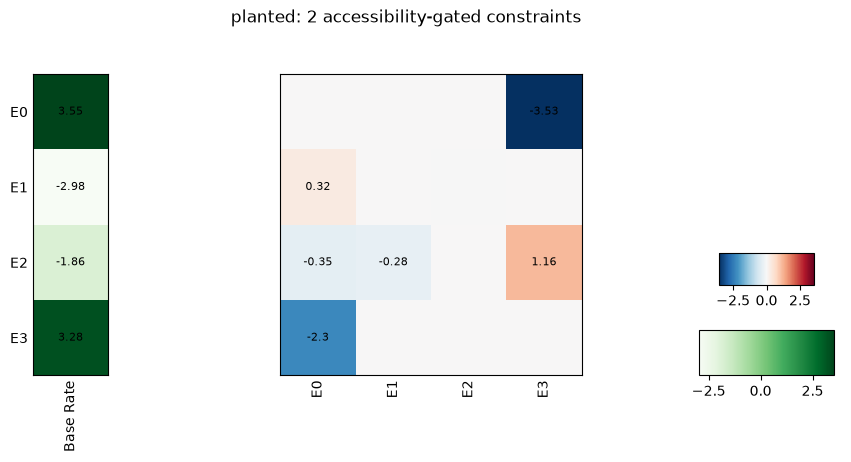

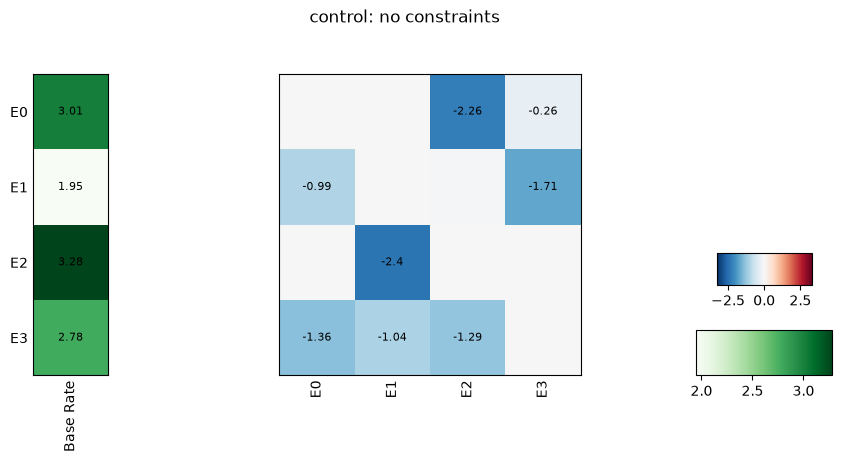

In [3]:
# `plot()` lays out its own 3-panel figure (base rates, Theta, colorbars) and ignores a supplied
# `ax` -- passing one leaves an empty extra panel behind. Let it draw, then size and title it: at
# four events its own figsize is small enough that the two colorbars' tick labels collide.
for m, title in ((model, f"planted: {len(dag)} accessibility-gated constraints"),
                 (model_ctl, "control: no constraints")):
    m.plot(annot=0.1)
    fig = plt.gcf()
    fig.set_size_inches(9, 4.4)
    fig.suptitle(title, y=1.04)
    plt.show()

## MHN's own figure: the likeliest progression orders

Given a fitted network, MHN can say which chronological order most likely produced each observed
patient state, and `plot_order_tree` aggregates those over the cohort: every root-to-leaf path is a
progression trajectory, and line width scales with how many patients took it.

This is inference, not observation — the matrix it was fitted to carries no order at all.

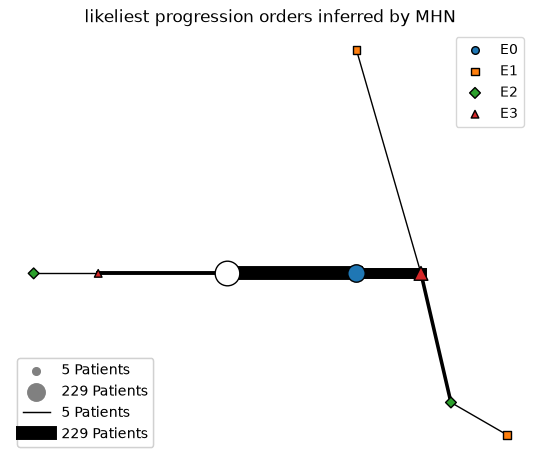

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
model.plot_order_tree(states=X.values.astype(np.int32), ax=ax,
                      min_number_of_occurrence=5, legend=True)
ax.set_title("likeliest progression orders inferred by MHN")
plt.show()

## What to take from it

MHN fits `iscc` cohorts in the shape real cross-sectional data comes in — one binary matrix, no
order, no clone sizes — and its own figures are readable straight off it: a Θ network, and the
progression orders that network implies for the observed patient states.

The second panel above is the same pipeline at the same penalty on a cohort grown identically but
**without** the planted constraints. A regularised network model fitted to a few hundred patients
will always report something, so that panel is what tells you how much of the first one is signal.

The network `iscc` actually planted, and everything else it recorded about this cohort, is laid out
in [The analysis dataset and its ground truth](analysis_ground_truth.ipynb).